In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("timoboz/tesla-stock-data-from-2010-to-2020")

print("Path to dataset files:", path)

100%|██████████| 46.1k/46.1k [00:00<00:00, 331kB/s]

Extracting files...
Path to dataset files: C:\Users\luis\.cache\kagglehub\datasets\timoboz\tesla-stock-data-from-2010-to-2020\versions\1


In [6]:
import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns
import scipy as sp

In [12]:
data=pd.read_csv(r"C:\Users\luis\code\python\pos-grad\series_temporais\TSLA.csv")

In [13]:
data.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
1,2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2,2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
3,2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
4,2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2416 entries, 0 to 2415
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2416 non-null   object 
 1   Open       2416 non-null   float64
 2   High       2416 non-null   float64
 3   Low        2416 non-null   float64
 4   Close      2416 non-null   float64
 5   Adj Close  2416 non-null   float64
 6   Volume     2416 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 132.3+ KB


In [15]:
data['Date']=pd.to_datetime(data['Date'])

In [16]:
uf=data[['Date','Close']]

In [17]:
print(uf.head())
print('*'*40)
print(uf.shape)

        Date      Close
0 2010-06-29  23.889999
1 2010-06-30  23.830000
2 2010-07-01  21.959999
3 2010-07-02  19.200001
4 2010-07-06  16.110001
****************************************
(2416, 2)


Text(0.5, 1.0, 'Tesla Stock Price')

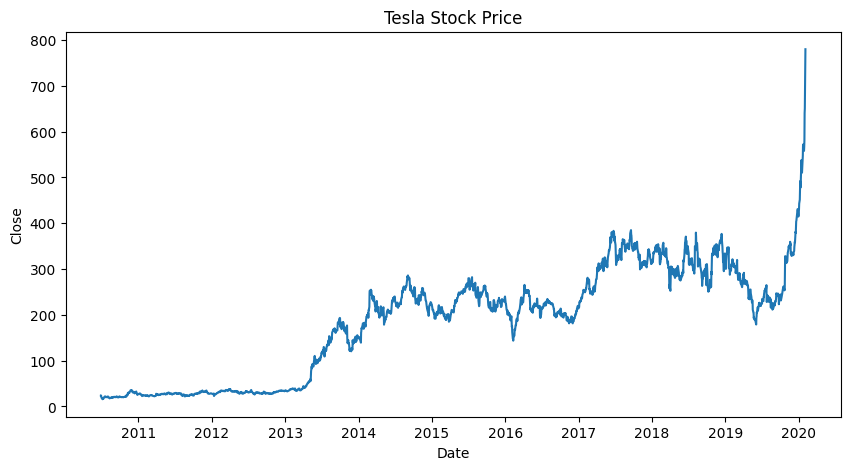

In [18]:
plt.figure(figsize=(10,5))
sns.lineplot(uf, x='Date', y='Close')
plt.title('Tesla Stock Price')

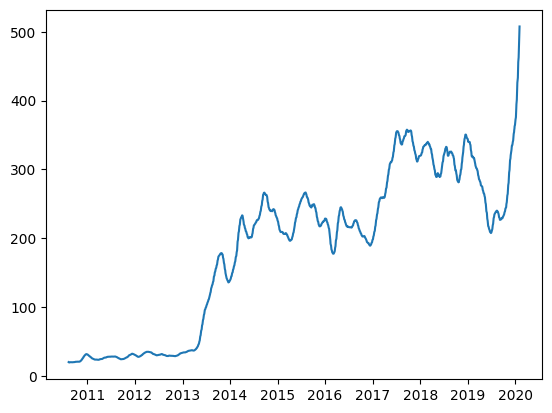

In [19]:
#Montly Simple Moving Average
plt.plot(uf['Date'],uf['Close'].rolling(30).mean())

<Axes: xlabel='Date', ylabel='Close'>

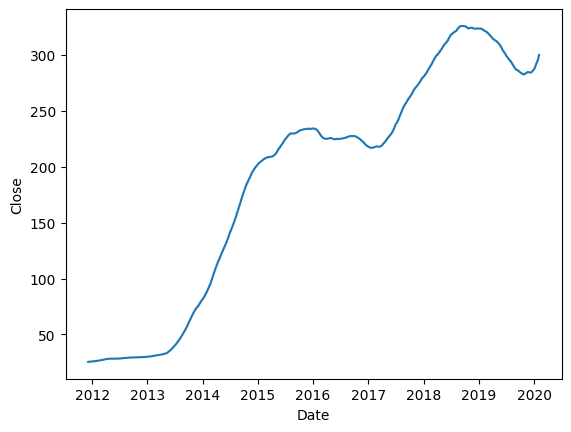

In [20]:
# Yearly Simple Moving Average
sns.lineplot(x=uf['Date'],y=uf['Close'].rolling(365).mean())

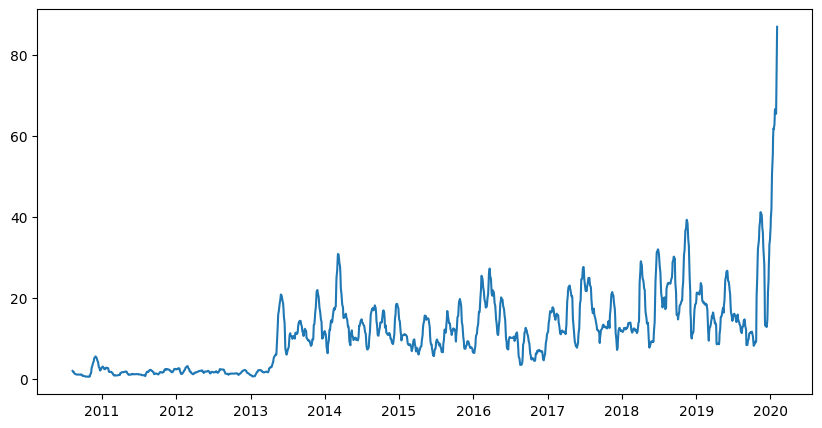

In [21]:
#Montly Standard deviation of Data
plt.figure(figsize=(10,5))
plt.plot(uf['Date'],uf['Close'].rolling(30).std())

In [22]:
from statsmodels.tsa.stattools import adfuller
adfuller(uf['Close'], autolag='AIC')

(np.float64(1.4000685020861596),
 np.float64(0.9971144530803391),
 18,
 2397,
 {'1%': np.float64(-3.4330810457844425),
  '5%': np.float64(-2.862746538733181),
  '10%': np.float64(-2.567412291147901)},
 np.float64(16128.395638116252))

In [23]:
def test_stationarity(timeseries):
    # Determing rolling statistics
    rolmean = timeseries.rolling(12).mean() # rolling mean
    rolstd = timeseries.rolling(12).std() # rolling standard deviation
    # Plot rolling statistics:
    plt.figure(figsize = (18,10))
    plt.grid('both')
    plt.plot(timeseries, color='blue',label='Original', linewidth = 3)
    plt.plot(rolmean, color='red', label='Rolling Mean',linewidth = 3)
    plt.plot(rolstd, color='black', label = 'Rolling Std',linewidth = 4)
    plt.legend(loc='best', fontsize = 20, shadow=True,facecolor='lightpink',edgecolor = 'k')
    plt.title('Rolling Mean and Standard Deviation', fontsize = 25)
    plt.xticks(fontsize = 15)
    plt.yticks(fontsize = 15)
    plt.show(block=False)
    
    print("Results of dickey fuller test")
    adft = adfuller(timeseries,autolag='AIC')
    # output for dft will give us without defining what the values are.
    # hence we manually write what values does it explains using a for loop
    output = pd.Series(adft[0:4],index=['Test Statistics','p-value','No. of lags used','Number of observations used'])
    for key,values in adft[4].items():
        output['critical value (%s)'%key] =  values
    print(output)

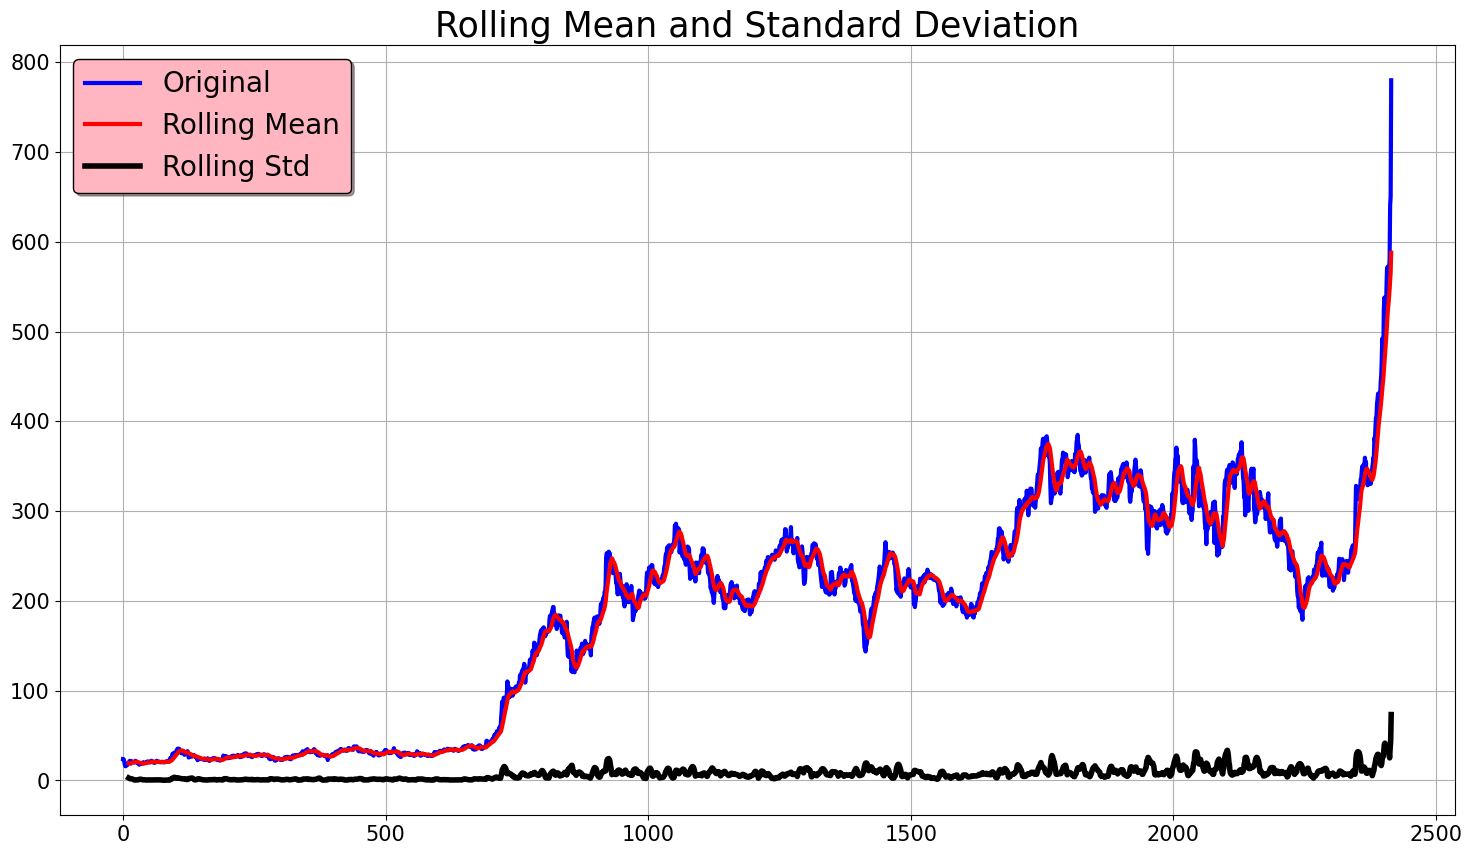

Results of dickey fuller test
Test Statistics                   1.400069
p-value                           0.997114
No. of lags used                 18.000000
Number of observations used    2397.000000
critical value (1%)              -3.433081
critical value (5%)              -2.862747
critical value (10%)             -2.567412
dtype: float64


In [24]:
test_stationarity(uf['Close'])

In [25]:
#Converting Non Stationary Data into Stationary Data
udf=uf.set_index('Date')

In [26]:
df_close=udf['Close'].diff()
df_close=df_close.dropna()

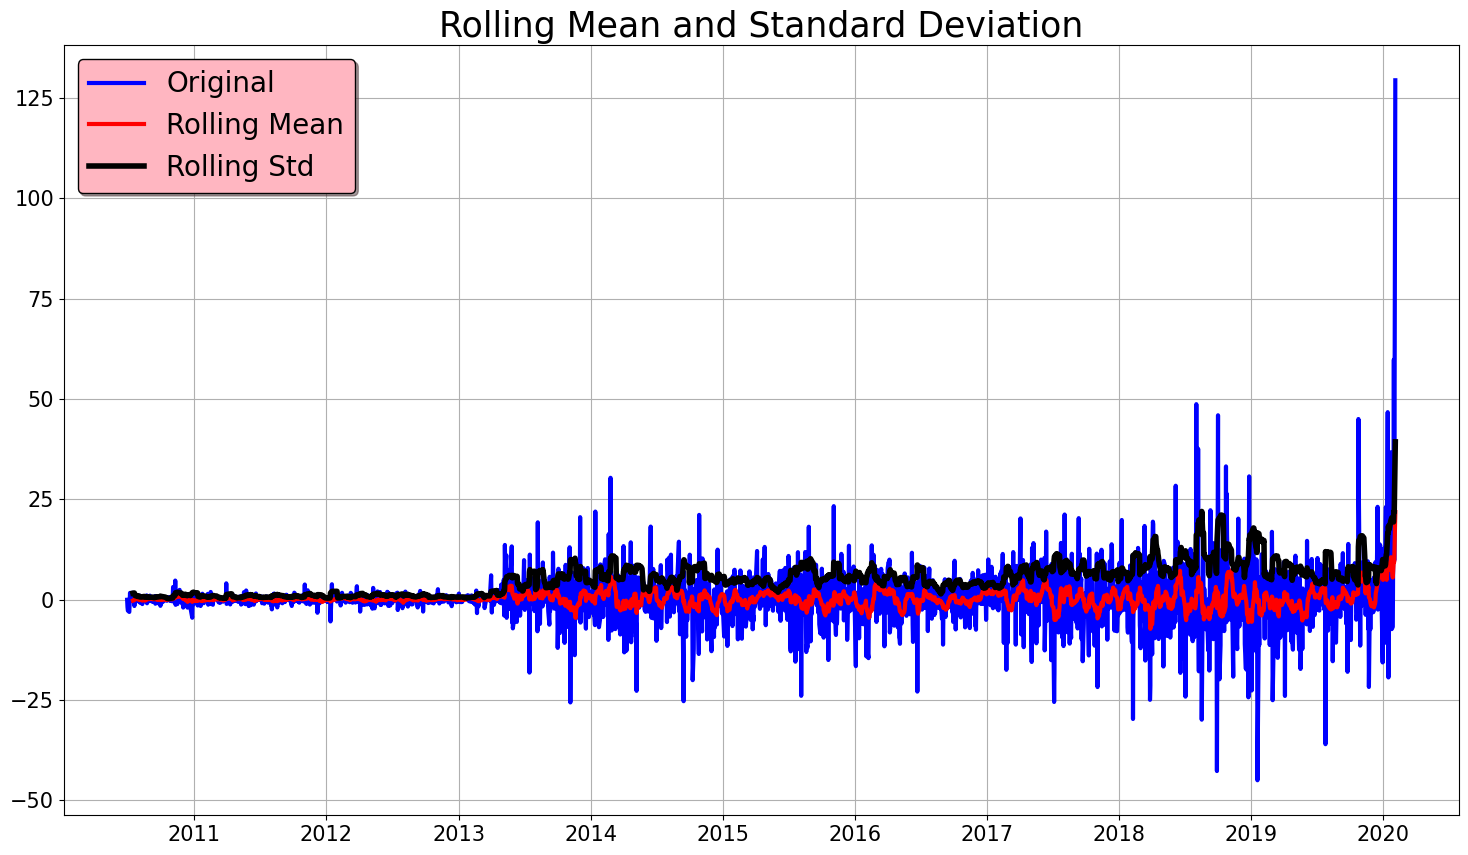

Results of dickey fuller test
Test Statistics               -6.151177e+00
p-value                        7.555858e-08
No. of lags used               1.700000e+01
Number of observations used    2.397000e+03
critical value (1%)           -3.433081e+00
critical value (5%)           -2.862747e+00
critical value (10%)          -2.567412e+00
dtype: float64


In [27]:
test_stationarity(df_close)

In [ ]:
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima_model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
import math
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [ ]:
# checking for Trend, Seasonality and residual
result=seasonal_decompose(uf['Close'], model='additive',extrapolate_trend='freq', period=30)
fig=plt.figure(figsize=(15,15))
fig=result.plot()
fig.set_size_inches(17,20)

In [ ]:
# checking for Trend, Seasonality and residual
result=seasonal_decompose(uf['Close'], model='multiplicative',extrapolate_trend='freq', period=30)
fig=plt.figure(figsize=(15,15))
fig=result.plot()
fig.set_size_inches(17,20)

In [ ]:
df_close.shape

In [ ]:
train_df=udf['Close'][0:-400]
test_df=udf['Close'][-400:]

In [ ]:
plt.figure(figsize=(18,10))
plt.grid(True)
plt.xlabel('Dates', fontsize=20)
plt.ylabel('Closing Price', fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.plot(train_df, 'green', label="Train",linewidth=5)
plt.plot(test_df, 'red', label='Test', linewidth=5)
plt.legend(fontsize=20, shadow=True, facecolor='lightpink', edgecolor='k')

## checking ARIMA Model as we have stationarised our data

### Autocorrelation function plot (ACF):

The ACF plot is used to determine which of these terms we should utilise for our time series.

* If the autocorrelation at lag 1 is positive, we utilise the AR model.
* If the autocorrelation at lag 1 is negative, we employ the MA model.

We move on to Partial Autocorrelation function plots (PACF) after plotting the ACF plot.

### Partial Autocorrelation function plot (PACF):
If the PACF plot drops off at lag n, then use an AR(n) model and if the drop in PACF is more gradual then we use the MA term.

Use AR terms in the model when the

* ACF plots show autocorrelation decaying towards zero
* PACF plot cuts off quickly towards zero
* ACF of a stationary series shows positive at lag-1

Use MA terms in the model when the model is

* Negatively Autocorrelated at Lag — 1
* ACF that drops sharply after a few lags
* PACF decreases more gradually

In [ ]:
var=df_close
var1=df_close[1:]
df=pd.DataFrame([var,var1])
df.T.corr

In [ ]:
fig = plt.figure(figsize=(12,12))
ax1 = fig.add_subplot(211)#function
fig = plot_acf(df_close, ax=ax1)
ax2 = fig.add_subplot(212)
fig = plot_pacf(df_close, ax=ax2)